# Gaussian Process Forecasting of Delhi Daily Temperature

- This notebook forecasts daily mean temperature from dates with a Gaussian Process fitted in GPyTorch.
- The analysis includes data checks, preparation, model fitting, future forecasts, test results, and uncertainty.

In [1]:
import json
import warnings

import gpytorch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from src.data import load_dataset
from src.model import build_model
from src.train import train_model
from src.evaluate import compute_metrics

warnings.filterwarnings("ignore", category=FutureWarning)
torch.manual_seed(42)
%matplotlib inline

C:\Users\alber\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


## 1. Dataset and Forecasting Objective

- The dataset comes from Kaggle (sumanthvrao, n.d.).
- The files contain daily Delhi weather measurements from 1 January 2013 through 24 April 2017: mean temperature, humidity, wind speed, and mean pressure.
- The model uses date to forecast `meantemp` in degrees Celsius for dates after the training period.

In [2]:
raw_train = pd.read_csv("DailyDelhiClimateTrain.csv", parse_dates=["date"])
raw_test = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=["date"])
print("Train:", raw_train.shape, raw_train["date"].min(), "->", raw_train["date"].max())
print("Test: ", raw_test.shape, raw_test["date"].min(), "->", raw_test["date"].max())
raw_train.describe()

Train: (1462, 5) 2013-01-01 00:00:00 -> 2017-01-01 00:00:00
Test:  (114, 5) 2017-01-01 00:00:00 -> 2017-04-24 00:00:00


,date,meantemp,humidity,wind_speed,meanpressure
count,1462,1462.000000,1462.000000,1462.000000,1462.000000
mean,2015-01-01 12:00:00,25.495521,60.771702,6.802209,1011.104548
min,2013-01-01 00:00:00,6.000000,13.428571,0.000000,-3.041667
25%,2014-01-01 06:00:00,18.857143,50.375000,3.475000,1001.580357
50%,2015-01-01 12:00:00,27.714286,62.625000,6.221667,1008.563492
75%,2016-01-01 18:00:00,31.305804,72.218750,9.238235,1014.944901
max,2017-01-01 00:00:00,38.714286,100.000000,42.220000,7679.333333
std,NaN,7.348103,16.769652,4.561602,180.231668


### Data Quality and Feature Scope

- Both files have complete daily dates and no missing values, so no imputation is needed.
- The files share 1 January 2017, which is removed from the test set to prevent overlap with training.
- Humidity, wind speed, and pressure are recorded in the files but are not inputs to this date-only model.

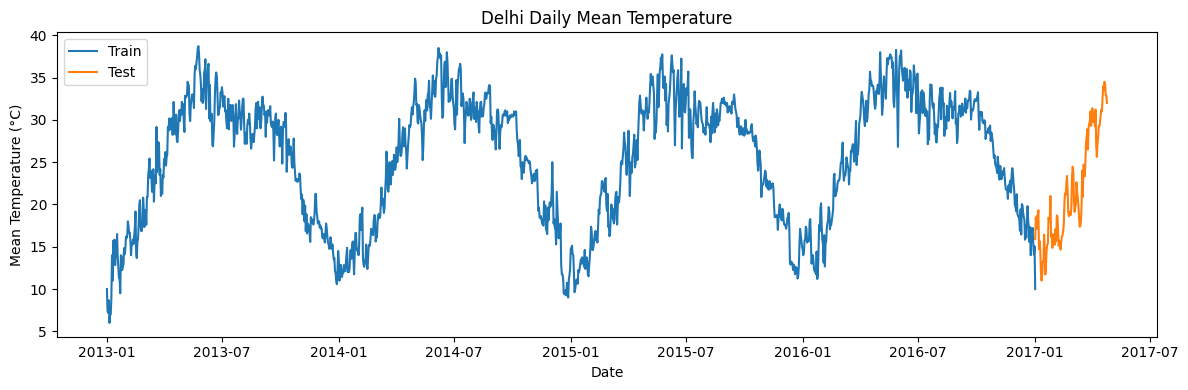

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(raw_train["date"], raw_train["meantemp"], label="Train")
ax.plot(raw_test["date"], raw_test["meantemp"], label="Test")
ax.set_title("Delhi Daily Mean Temperature")
ax.set_xlabel("Date"); ax.set_ylabel("Mean Temperature (°C)"); ax.legend()
plt.tight_layout(); plt.show()

## 2. Preprocessing and Temporal Split

- The chronological training set has 1,462 observations from 1 January 2013 through 1 January 2017, and the test set has 113 observations from 2 January through 24 April 2017.
- Dates are converted to years elapsed since the first training date by dividing elapsed days by 365.
- Temperature is standardized with the training mean and standard deviation only, then converted back to degrees Celsius for plots and scores.

In [4]:
ds = load_dataset()
print(f"Train: {len(ds.x_train)} points | Test: {len(ds.x_test)} points")
print(f"Target standardization -> mean={ds.y_mean:.3f}, std={ds.y_std:.3f}")
print(f"x range (years since start) -> train: [{ds.x_train.min():.2f}, {ds.x_train.max():.2f}], "
      f"test: [{ds.x_test.min():.2f}, {ds.x_test.max():.2f}]")

Train: 1462 points | Test: 113 points
Target standardization -> mean=25.496, std=7.346
x range (years since start) -> train: [0.00, 4.00], test: [4.01, 4.31]


## 3. Gaussian Process Model and Kernel Design

- The `gpytorch.models.ExactGP` regression model uses a constant mean and a Gaussian likelihood for observation noise (GPyTorch, n.d.).
- Its covariance is the sum of a long-range RBF kernel, a periodic kernel for the annual cycle, and a short-range RBF kernel, each with a learned output scale.
- The trend lengthscale exceeds 0.5 years, the seasonal period lies between 0.8 and 1.2 years, and the local lengthscale is below 0.15 years.
- The trend and seasonal kernel design follows the approach described by Rasmussen and Williams (2006).

In [5]:
model, likelihood = build_model(ds.x_train, ds.y_train)
print(model.covar_module)

AdditiveKernel(
  (kernels): ModuleList(
    (0): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): GreaterThan(5.000E-01)
      )
      (raw_outputscale_constraint): Positive()
    )
    (1): ScaleKernel(
      (base_kernel): PeriodicKernel(
        (raw_lengthscale_constraint): Positive()
        (raw_period_length_constraint): Interval(8.000E-01, 1.200E+00)
      )
      (raw_outputscale_constraint): Positive()
    )
    (2): ScaleKernel(
      (base_kernel): RBFKernel(
        (raw_lengthscale_constraint): LessThan(1.500E-01)
      )
      (raw_outputscale_constraint): Positive()
    )
  )
)


## 4. Hyperparameter Optimization

- Adam minimizes negative exact marginal log likelihood for 500 iterations from a learning rate of 0.02 with cosine annealing.
- The fitted trend lengthscale is 2.680 years, the seasonal period is 0.998 years, and the local lengthscale is 1.865 days.
- The fitted seasonal lengthscale is 0.318, and the observation-noise standard deviation is 0.138 in standardized temperature units.
- The fitted output scales are 0.169 for the trend, 0.985 for seasonality, and 0.079 for the local kernel.

Iter    1/500 - loss: 0.8354 - noise: 0.6833


Iter   25/500 - loss: 0.6745 - noise: 0.4743


Iter   50/500 - loss: 0.5038 - noise: 0.3141


Iter   75/500 - loss: 0.3539 - noise: 0.2072


Iter  100/500 - loss: 0.2364 - noise: 0.1417


...

Iter  400/500 - loss: -0.1260 - noise: 0.0197


Iter  425/500 - loss: -0.1146 - noise: 0.0193


Iter  450/500 - loss: -0.0820 - noise: 0.0192


Iter  475/500 - loss: -0.1006 - noise: 0.0191


Iter  500/500 - loss: -0.1277 - noise: 0.0191


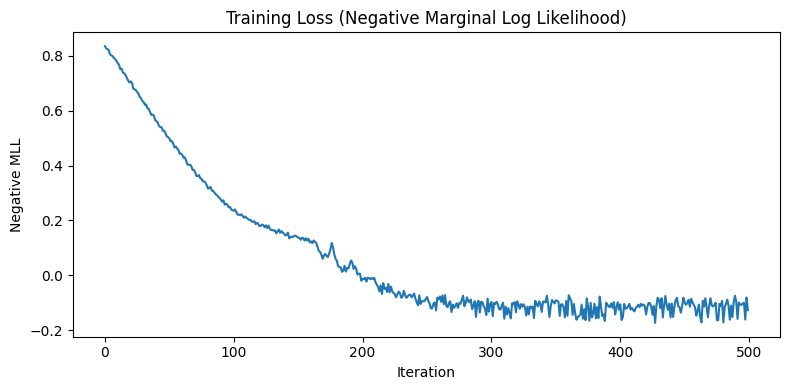

In [6]:
loss_history = train_model(model, likelihood, ds.x_train, ds.y_train, n_iter=500, lr=0.02)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_history)
ax.set_title("Training Loss (Negative Marginal Log Likelihood)")
ax.set_xlabel("Iteration"); ax.set_ylabel("Negative MLL")
plt.tight_layout(); plt.show()

In [7]:
trend, seasonal, local = model.covar_module.kernels
print("Learned hyperparameters:")
print(f"  Trend RBF lengthscale:   {trend.base_kernel.lengthscale.item():.3f} years")
print(f"  Seasonal period:         {seasonal.base_kernel.period_length.item():.3f} years")
print(f"  Seasonal lengthscale:    {seasonal.base_kernel.lengthscale.item():.3f}")
print(f"  Local RBF lengthscale:   {local.base_kernel.lengthscale.item() * 365:.1f} days")
print(f"  Observation noise (std): {likelihood.noise.sqrt().item():.4f} (standardized units)")
print(f"  Output scales (trend/seasonal/local): {trend.outputscale.item():.3f} / {seasonal.outputscale.item():.3f} / {local.outputscale.item():.3f}")

Learned hyperparameters:
  Trend RBF lengthscale:   2.680 years
  Seasonal period:         0.998 years
  Seasonal lengthscale:    0.318
  Local RBF lengthscale:   1.9 days
  Observation noise (std): 0.1381 (standardized units)
  Output scales (trend/seasonal/local): 0.169 / 0.985 / 0.079


## 5. Probabilistic Forecasting

- The fitted model forecasts the 113 held-out dates without using their observed temperatures.
- Applying the Gaussian likelihood gives a predictive mean and variance for each observed daily temperature.
- Each plotted 95% predictive interval is the mean plus or minus 1.96 predictive standard deviations in degrees Celsius.

In [8]:
model.eval(); likelihood.eval()
with torch.no_grad():
    posterior = likelihood(model(ds.x_test))
    pred_mean_scaled = posterior.mean
    pred_std_scaled = posterior.variance.sqrt()

test_mean = ds.unscale_y(pred_mean_scaled)
test_std = pred_std_scaled * ds.y_std
y_true = ds.unscale_y(ds.y_test)

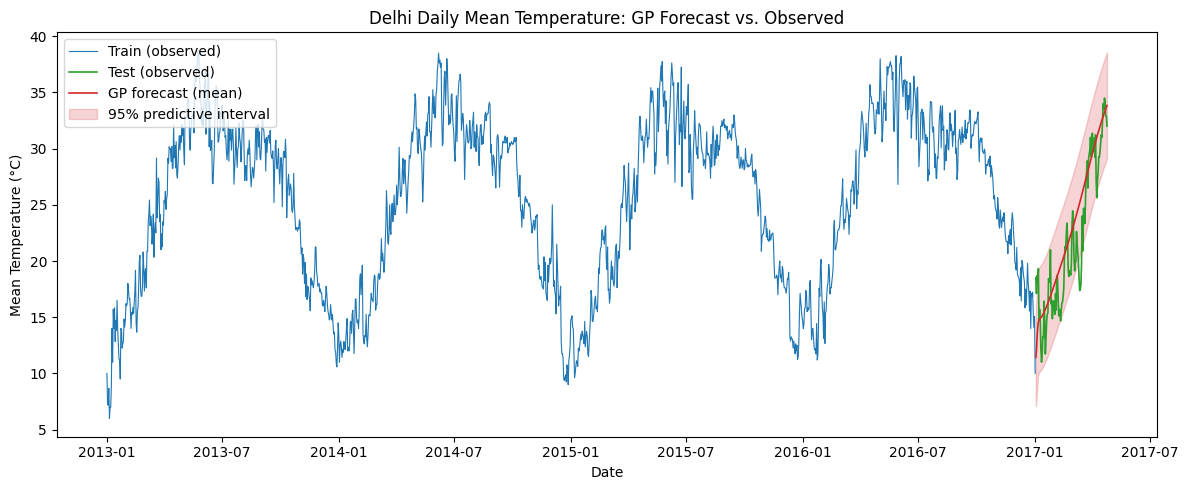

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ds.train_dates, ds.unscale_y(ds.y_train), color="#1f77b4", lw=0.8, label="Train (observed)")
ax.plot(ds.test_dates, y_true, color="#2ca02c", lw=1.2, label="Test (observed)")
ax.plot(ds.test_dates, test_mean, color="#d62728", lw=1.2, label="GP forecast (mean)")
ax.fill_between(ds.test_dates, test_mean - 1.96 * test_std, test_mean + 1.96 * test_std,
                 color="#d62728", alpha=0.2, label="95% predictive interval")
ax.set_title("Delhi Daily Mean Temperature: GP Forecast vs. Observed")
ax.set_xlabel("Date"); ax.set_ylabel("Mean Temperature (°C)"); ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

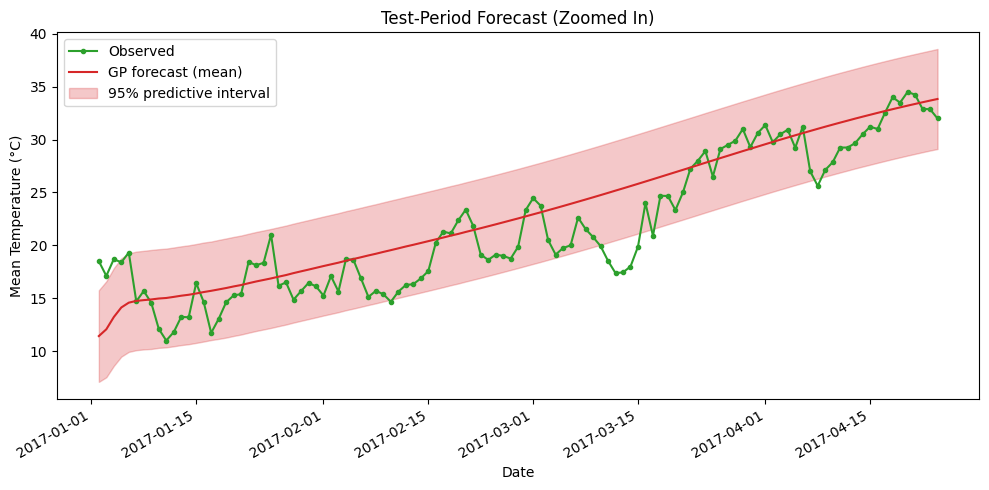

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ds.test_dates, y_true, "o-", color="#2ca02c", ms=3, label="Observed")
ax.plot(ds.test_dates, test_mean, color="#d62728", label="GP forecast (mean)")
ax.fill_between(ds.test_dates, test_mean - 1.96 * test_std, test_mean + 1.96 * test_std,
                 color="#d62728", alpha=0.25, label="95% predictive interval")
ax.set_title("Test-Period Forecast (Zoomed In)")
ax.set_xlabel("Date"); ax.set_ylabel("Mean Temperature (°C)"); ax.legend(loc="upper left")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 6. Forecast Evaluation

- MSE, RMSE, and MAE compare the forecast means with the observed test temperatures.
- Mean predictive log likelihood scores each observation under its predictive Gaussian, and mean NLPD is the negative of that score.
- Coverage is the share of observed test temperatures inside their 95% predictive intervals.

In [11]:
metrics = compute_metrics(y_true, test_mean, test_std)
print(json.dumps(metrics.as_dict(), indent=2))

{
  "MSE": 9.054550170898438,
  "RMSE": 3.0090779602560045,
  "MAE": 2.4019455909729004,
  "Mean predictive log likelihood (nats)": -2.5893795490264893,
  "Mean NLPD": 2.5893795490264893,
  "95% predictive interval coverage": 0.8849557522123894
}


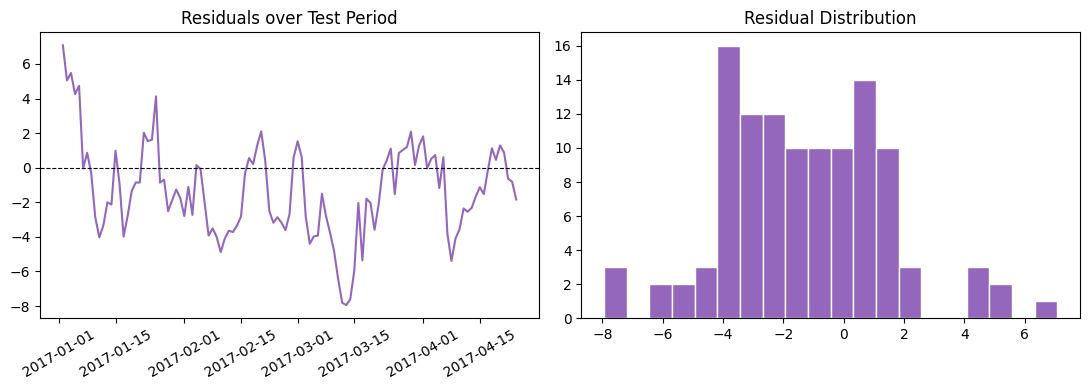

In [12]:
residuals = (y_true - test_mean).numpy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(ds.test_dates, residuals, color="#9467bd")
axes[0].axhline(0, color="black", lw=0.8, ls="--")
axes[0].set_title("Residuals over Test Period"); axes[0].tick_params(axis="x", rotation=30)
axes[1].hist(residuals, bins=20, color="#9467bd", edgecolor="white")
axes[1].set_title("Residual Distribution")
plt.tight_layout(); plt.show()

## 7. Observations

- Test MSE is 9.055 °C², RMSE is 3.009 °C, and MAE is 2.402 °C.
- Mean predictive log likelihood is −2.589 nats per observation, and mean NLPD is 2.589.
- The 95% predictive intervals contain 100 of 113 test observations, or 88.5%.

## 8. Final Insights

- The fitted seasonal period is close to one year, consistent with the annual pattern in the training temperatures.
- The forecast mean follows the rise in temperature through the test period, but the intervals fall short of 95% coverage.
- These intervals describe possible future observations, including observation noise, rather than uncertainty in the mean alone.

## 9. Recommendations

- Check forecast errors and interval coverage across several rolling test periods before using the model for longer forecasts.
- Compare this kernel with simpler seasonal models and adjust the uncertainty estimate if undercoverage persists.
- Test weather covariates only when their values are available before the forecast date.

## 10. Report

- The [Word report](report/GP_Forecasting_Report_APA.docx) documents the dataset, preparation, kernel and fitted parameters, training, forecasts, test scores, and predictive intervals.
- The separate assignment rubric was not supplied, so the report follows the criteria listed in the assignment instructions.

## References

<p style="margin-left: 0.5in; text-indent: -0.5in;">GPyTorch. (n.d.). <em>GPyTorch regression tutorial</em>. Retrieved September 16, 2026, from <a href="https://docs.gpytorch.ai/en/stable/examples/01_Exact_GPs/Simple_GP_Regression.html">https://docs.gpytorch.ai/en/stable/examples/01_Exact_GPs/Simple_GP_Regression.html</a></p>

<p style="margin-left: 0.5in; text-indent: -0.5in;">Rasmussen, C. E., &amp; Williams, C. K. I. (2006). <em>Gaussian processes for machine learning</em>. MIT Press. <a href="https://gaussianprocess.org/gpml/">https://gaussianprocess.org/gpml/</a></p>

<p style="margin-left: 0.5in; text-indent: -0.5in;">sumanthvrao. (n.d.). <em>Daily climate time series data</em> [Data set]. Kaggle. <a href="https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data">https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data</a></p>